# Shape Working Memory (MNM) — Baseline SVM Decoding

Baseline high-gamma SVM decoding for the shape task, following the pipeline in `docs/DecodingLogic_Hackathon.pdf`. Decodes the cued shape identity (class 1-8).

Pipeline (the Raw/CAR/Laplacian fields are broadband voltage traces, not directly classifier-ready features):

1. 70-150 Hz bandpass -> Hilbert amplitude envelope (high-gamma power over time)
2. moving-average smoothing (~488 ms) + downsample
3. per-trial z-score to the 0.25-0.75 s fixation window
4. keep channels with >= 3 trials in **every** class (8 classes)
5. standardise to 3 trials/class, stack channels -> `[trials x channels x time]`
6. per time bin: `StandardScaler` -> linear SVM (One-vs-All), Stratified Leave-One-Per-Class-Out CV
7. repeat with random channel subsampling to equalise dorsal/ventral sizes

Reusable functions live in `scripts/decoding.py`; this notebook drives them and plots the results.

In [1]:
import sys, warnings
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")          # silence LinearSVC convergence chatter
%matplotlib inline
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True

ROOT = Path.cwd()
REPO = ROOT if (ROOT / "scripts" / "seeg_io.py").exists() else ROOT.parent
sys.path.insert(0, str(REPO / "scripts"))

from seeg_io import SEEGDataset
from decoding import (
    build_pseudopopulation, time_resolved_accuracy, static_accuracy,
    region_decoding_curve,
)
print("repo root:", REPO.name)


repo root: human-decoding-hackathon


## 1. Load the dataset and screen channels

In [2]:
DATA_PATH = REPO / "data" / "Prefrontal_MNM_Session.mat"
N_CLASSES = 8

ds = SEEGDataset(DATA_PATH)
summary = ds.summary()
print(f"task={ds.task}  channels={len(ds)}  fs={ds.fs} Hz  trial≈9.5 s")

# channels usable for time-resolved decoding: >=3 trials in EVERY class
viable = set(ds.viable_channels(min_trials_per_class=3, required_classes=N_CLASSES))
dorsal  = [i for i in summary.loc[summary.prefrontal_subdiv == "Dorsal",  "idx"] if i in viable]
ventral = [i for i in summary.loc[summary.prefrontal_subdiv == "Ventral", "idx"] if i in viable]
print(f"viable channels: {len(viable)}  (Dorsal {len(dorsal)}, Ventral {len(ventral)})")
print(f"chance level = 1/{N_CLASSES} = {1/N_CLASSES:.3f}")


task=Shape  channels=646  fs=512.0 Hz  trial≈9.5 s


viable channels: 256  (Dorsal 115, Ventral 141)
chance level = 1/8 = 0.125


## 2. Build one pseudo-population and inspect it

Each channel is recorded independently and carries its own trials. We draw 3 trials per class from every channel and stack channels into a `[trials × channels × time]` tensor — a pseudo-population. `REF` selects the referencing scheme (Milestone 4 compares all three).

In [3]:
REF = "Laplacian"          # "TrialData" (raw) | "Common" (CAR) | "Laplacian"

pop = build_pseudopopulation(ds, dorsal, ref=REF, n_trials_per_class=3,
                             downsample=20, seed=0)
print("tensor  [trials x channels x time] :", pop.X.shape)
print("classes :", np.unique(pop.y), " chance :", round(pop.chance, 3))
print("time    :", f"{pop.time_s[0]:.2f} .. {pop.time_s[-1]:.2f} s, {pop.X.shape[2]} bins")


tensor  [trials x channels x time] : (24, 113, 244)
classes : [1 2 3 4 5 6 7 8]  chance : 0.125
time    : 0.00 .. 9.49 s, 244 bins


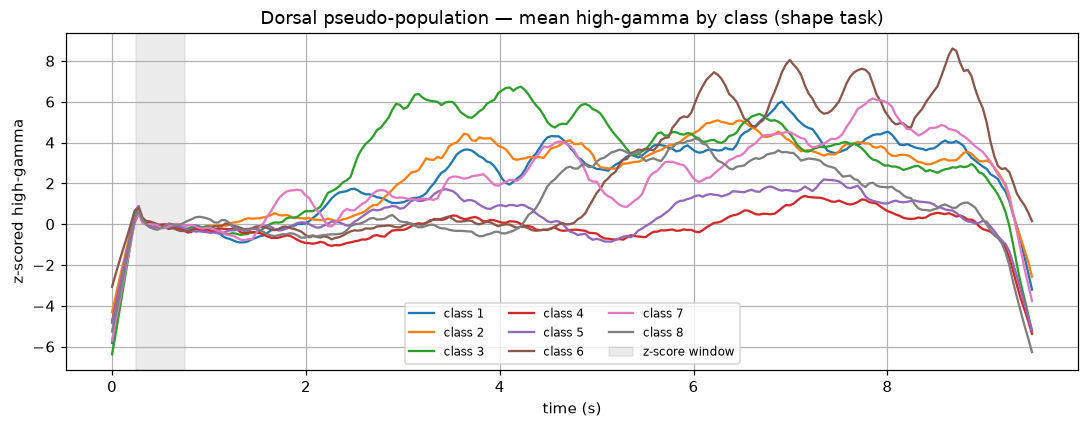

In [4]:
# mean high-gamma envelope per class (dorsal pseudo-population)
fig, ax = plt.subplots(figsize=(10, 4))
for c in np.unique(pop.y):
    ax.plot(pop.time_s, pop.X[pop.y == c].mean(axis=(0, 1)), label=f"class {c}")
ax.axvspan(0.25, 0.75, color="grey", alpha=0.15, label="z-score window")
ax.set_xlabel("time (s)"); ax.set_ylabel("z-scored high-gamma")
ax.set_title("Dorsal pseudo-population — mean high-gamma by class (shape task)")
ax.legend(ncol=3, fontsize=8)
plt.tight_layout()


- Sampling rate: 512 Hz; trial duration ≈ 9.45 s → ~4,838 original time points
- High-gamma smoothing: 488-ms moving-average window (~250 original samples)
- Normalization: z-scored within each trial using the 0.25–0.75 s baseline window
- Downsampling: factor = 20 → 25.6 Hz effective sampling rate
- Step size: 20/512 s ≈ 39.1 ms between adjacent time bins
- Final temporal dimension: 244 time bins over the ~9.5-s trial


Logic in decoding.py
```
Laplacian sEEG signal
        ↓
Band-pass filter (High-Gamma band)
        ↓
extract High-Gamma envelope
        ↓
488-ms moving-average smoothing
        ↓
0.25–0.75 s baseline z-score
        ↓
  Downsample ×20
        ↓
 High-Gamma feature
        ↓
     pop.X[:, :, t]
        ↓
SVM / decoding
```

## 3. Static baseline — decode from the delay-window average

Simplest possible SVM baseline: average the high-gamma over a delay window
(**2.0-6.0 s**, approximate - the file has no epoch markers) -> one feature vector per trial -> SLOO CV.

In [5]:
DELAY_WIN = (2.0, 6.0)

for name, chans in [("Dorsal", dorsal), ("Ventral", ventral)]:
    accs = []
    for s in range(5):                       # 5 channel subsamples
        sub = list(np.random.default_rng(s).choice(chans, size=min(60, len(chans)), replace=False))
        p = build_pseudopopulation(ds, sub, ref=REF, n_trials_per_class=3, downsample=20, seed=s)
        accs.append(static_accuracy(p, DELAY_WIN, C=0.1, n_cv_repeats=5, seed=s))
    print(f"{name:8s} delay-window decoding accuracy = {np.mean(accs):.3f} ± {np.std(accs):.3f}"
          f"   (chance {1/N_CLASSES:.3f})")


Dorsal   delay-window decoding accuracy = 0.193 ± 0.090   (chance 0.125)


Ventral  delay-window decoding accuracy = 0.123 ± 0.050   (chance 0.125)


## 4. Time-resolved decoding — Dorsal vs Ventral

The Milestone 3 deliverable: one classifier per time bin, dorsal and ventral channel counts equalised by random subsampling, averaged over subsamples. `X` = time (s), `Y` = cross-validated decoding accuracy.

In [6]:
res = region_decoding_curve(
    ds,
    {"Dorsal": dorsal, "Ventral": ventral},
    ref=REF,
    n_channels=min(60, len(dorsal), len(ventral)),
    n_channel_resamples=3,      # raise to 10 for a publication-quality curve
    n_cv_repeats=5,
    downsample=20,
    seed=0,
)


shared classes: [1, 2, 3, 4, 5, 6, 7, 8]  (chance = 0.125)


  Dorsal: resample 1/3 (peak acc 0.26)


  Dorsal: resample 2/3 (peak acc 0.22)


  Dorsal: resample 3/3 (peak acc 0.39)


  Ventral: resample 1/3 (peak acc 0.27)


  Ventral: resample 2/3 (peak acc 0.33)


  Ventral: resample 3/3 (peak acc 0.32)


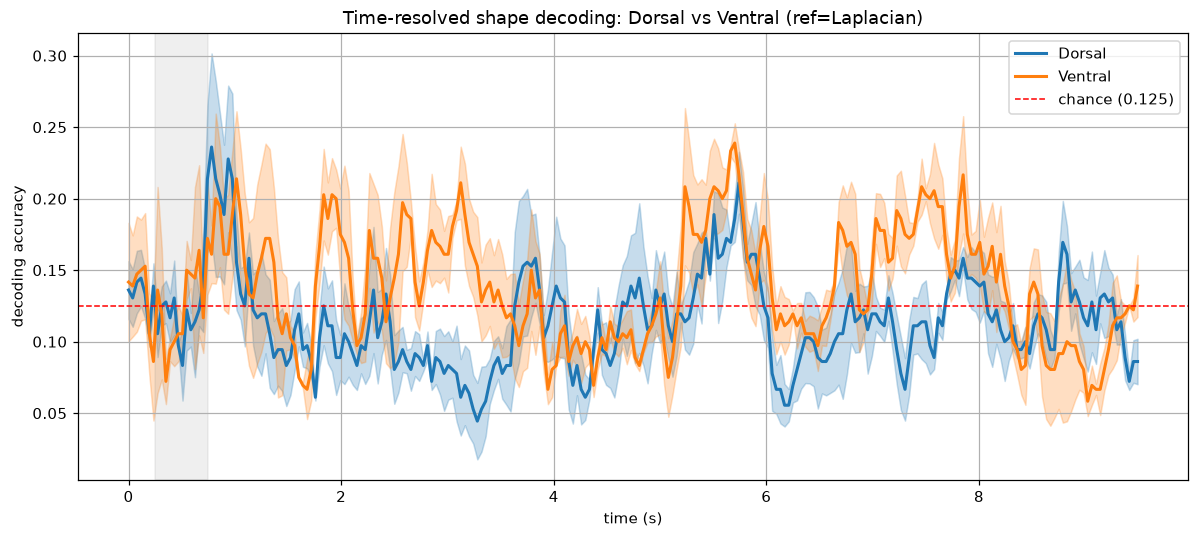

In [7]:
fig, ax = plt.subplots(figsize=(11, 5))
colors = {"Dorsal": "tab:blue", "Ventral": "tab:orange"}
for region, d in res.items():
    t, m, se = d["time_s"], d["mean"], d["sem"]
    ax.plot(t, m, color=colors[region], lw=2, label=region)
    ax.fill_between(t, m - se, m + se, color=colors[region], alpha=0.25)

chance = next(iter(res.values()))["chance"]
ax.axhline(chance, color="red", ls="--", lw=1, label=f"chance ({chance:.3f})")
ax.axvspan(0.25, 0.75, color="grey", alpha=0.12)
ax.set_xlabel("time (s)"); ax.set_ylabel("decoding accuracy")
ax.set_title(f"Time-resolved shape decoding: Dorsal vs Ventral (ref={REF})")
ax.legend()
plt.tight_layout()


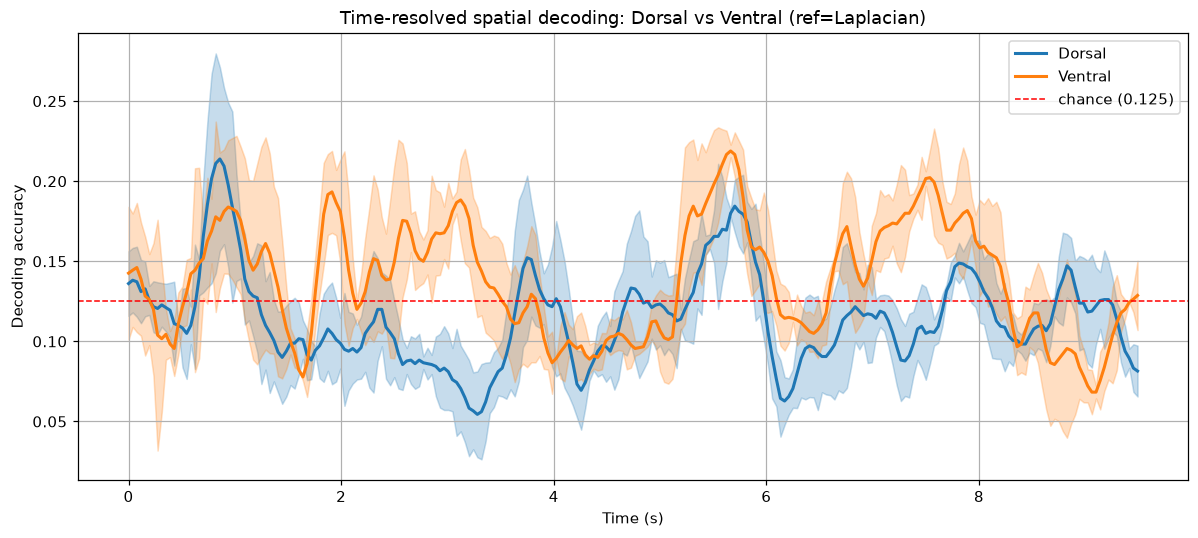

In [8]:
# same curve, 5-point (~195 ms) moving average for display only
def _smooth(x, w=5):
    k = np.ones(w) / w
    return np.convolve(np.pad(x, w // 2, mode="edge"), k, mode="valid")[: len(x)]

fig, ax = plt.subplots(figsize=(11, 5))
for region, d in res.items():
    m = _smooth(d["mean"])
    ax.plot(d["time_s"], m, color=colors[region], lw=2, label=region)
    ax.fill_between(d["time_s"], m - d["sem"], m + d["sem"], color=colors[region], alpha=0.25)
ax.axhline(chance, color="red", ls="--", lw=1, label=f"chance ({chance:.3f})")
ax.set_xlabel("time (s)"); ax.set_ylabel("decoding accuracy")
ax.set_title(f"Time-resolved shape decoding: Dorsal vs Ventral (ref={REF})")
ax.legend()
plt.tight_layout()

In [9]:
# crude peak-latency readout (a formal latency contrast needs a cluster-based permutation test)
for region, d in res.items():
    i = int(np.argmax(d["mean"]))
    print(f"{region:8s} peak accuracy {d['mean'][i]:.3f} at t = {d['time_s'][i]:.2f} s")


Dorsal   peak accuracy 0.236 at t = 0.78 s
Ventral  peak accuracy 0.239 at t = 5.70 s
